In [1]:
import numpy as np
from gpaw.external import ExternalPotential
from gpaw.poisson import NoInteractionPoissonSolver


class ChargedPlanePotential(ExternalPotential):
    def __init__(self, A, z_plane):
        self.A = A
        self.z_plane = z_plane

    def calculate_potential(self, gd):
        r_vg = gd.get_grid_point_coordinates()
        z = r_vg[2]

        V = -self.A * np.abs(z - self.z_plane)

        # REMOVE CONSTANT OFFSET
        self.vext_g = V - V.mean()

    def todict(self):
        return {
            'name': 'ChargedPlanePotential',
            'A': self.A,
            'z_plane': self.z_plane
        }


In [52]:
from gpaw import restart

atoms, calc = restart('../gpw/ab.gpw')
z_plane = atoms.positions[:,2].mean()  +  3   # somewhere in the vacuum above the bilayer
A = 0.005                            # tune this, start small

pos = atoms.positions
z_atoms = pos[:, 2]

z_min = z_atoms.min()
z_max = z_atoms.max()
z_center = 0.5 * (z_min + z_max)

# Example: top gate 3 Å above the top layer
z_plane = z_max + 3.0  # Å

ext = ChargedPlanePotential(A=A, z_plane=z_plane)  # example
gd = calc.hamiltonian.xc_gd

# Compute the potential on the GPAW grid
ext.calculate_potential(gd)

Vext = ext.vext_g                 # <-- THIS is your potential
r = gd.get_grid_point_coordinates()
x, y, z = r

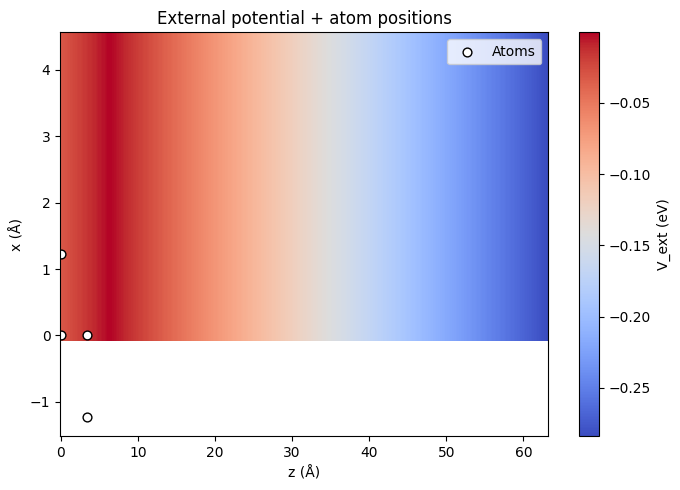

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Average over y → get a clean x–z plane
V_xz = Vext.mean(axis=1)  # shape (nx, nz)

# Coordinates for axes
x_vals = x[:, 0, 0]
z_vals = z[0, 0, :]

# --- Your potential slice ---
plt.figure(figsize=(7,5))
plt.pcolormesh(z_vals, x_vals, V_xz, shading='auto', cmap='coolwarm')
plt.colorbar(label='V_ext (eV)')
plt.xlabel('z (Å)')
plt.ylabel('x (Å)')
plt.title('External potential + atom positions')

# --- Overlay atoms ---
# Extract atomic positions
pos = atoms.positions   # shape (Natoms, 3)
x_atoms = pos[:,0]
z_atoms = pos[:,2]

# Plot atoms as points
plt.scatter(z_atoms, x_atoms,
            color='white', s=40, edgecolors='black',
            label='Atoms')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [54]:
from ase.dft.kpoints import get_bandpath

# Restart the converged zero-field calculation

# Choose gate position and strength


# Tell GPAW to use this external potential and write to a new txt
calc.set(external=ext, txt='ab_gate_plane_A0.1.txt')

# Re-run SCF with the new Hamiltonian (now including the gate)
atoms.calc = calc
atoms.get_potential_energy()   # this does the SCF loop
calc.write('../gpw/ab_gate_plane_A0.1.gpw')


In [55]:
from gpaw import GPAW
from gpaw.external import known_potentials
#known_potentials['ChargedPlanePotential'] = ChargedPlanePotential
# Build the same k-path as before, e.g. Γ-K-M-ΓGPAW('../gpw/ab_gate_plane_A0.1.gpw')
bs_calc = calc.fixed_density(
    nbands=16,
    symmetry='off',
    kpts={'path': 'GKMG', 'npoints': 30},
    convergence={'bands': 8},
)

bs = bs_calc.band_structure()




  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Wed Dec 10 13:01:59 2025
Arch:   x86_64
Pid:    2173
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.005,
             name: ChargedPlanePotential,
             z_plane: 6.35}
  gpts: [ 14  14 192]
  kpts: {npoints: 30,
         pat

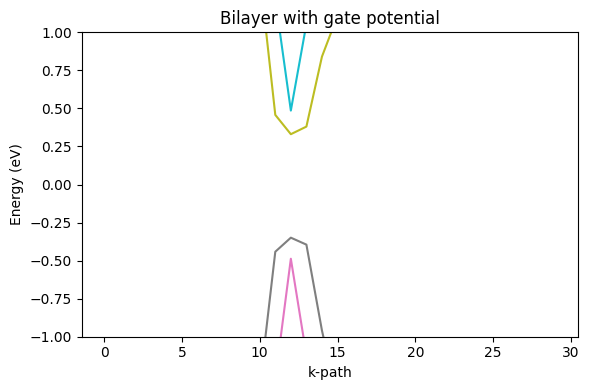

In [56]:
energies = bs.energies[0]             # (Nk, Nbands)
EF = calc.get_fermi_level()
E_shift = energies - EF

# Simple matplotlib plot
import matplotlib.pyplot as plt
x = bs.path.kpts  # distances along the path

plt.figure(figsize=(6,4))
for n in range(E_shift.shape[1]):
    plt.plot(E_shift[:, n])

#for xk in bs.path.special_points:
#    plt.axvline(xk, color='gray', lw=0.5)

plt.ylim(-1, 1)
plt.xlabel('k-path')
plt.ylabel('Energy (eV)')
plt.title('Bilayer with gate potential')
plt.tight_layout()
plt.show()

In [23]:
x

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.02777778, -0.02777778,  0.        ],
       [ 0.05555556, -0.05555556,  0.        ],
       [ 0.08333333, -0.08333333,  0.        ],
       [ 0.11111111, -0.11111111,  0.        ],
       [ 0.13888889, -0.13888889,  0.        ],
       [ 0.16666667, -0.16666667,  0.        ],
       [ 0.19444444, -0.19444444,  0.        ],
       [ 0.22222222, -0.22222222,  0.        ],
       [ 0.25      , -0.25      ,  0.        ],
       [ 0.27777778, -0.27777778,  0.        ],
       [ 0.30555556, -0.30555556,  0.        ],
       [ 0.33333333, -0.33333333,  0.        ],
       [ 0.36111111, -0.27777778,  0.        ],
       [ 0.38888889, -0.22222222,  0.        ],
       [ 0.41666667, -0.16666667,  0.        ],
       [ 0.44444444, -0.11111111,  0.        ],
       [ 0.47222222, -0.05555556,  0.        ],
       [ 0.5       ,  0.        ,  0.        ],
       [ 0.45454545,  0.        ,  0.        ],
       [ 0.40909091,  0.        ,  0.   

In [18]:
E_shift[:, n]

array([12.90947141, 12.7398115 , 12.23093347, 11.51029817, 12.10037911,
       12.65733387, 13.11372636, 13.5143232 , 13.85677176, 14.14807797,
       14.68038961, 15.16848269, 15.42254581, 14.78784028, 14.35091612,
       14.62145379, 14.68560391, 14.77218345, 17.73992474, 17.42645425,
       16.37049266, 14.93977417, 14.43143845, 14.01983144, 13.70210507,
       12.75763579, 11.56344774, 12.30069689, 12.7580891 , 12.90947141])

In [14]:
E_shift[:, 1]

array([-18.10504644, -18.05039772, -17.88667789, -17.61448832,
       -17.23485742, -16.74949121, -16.16088077, -15.4728689 ,
       -14.69145409, -13.82955614, -14.66483172, -15.41269635,
       -16.06038607, -15.75202292, -15.87171729, -16.10393668,
       -16.30851572, -16.4411931 , -16.48670343, -15.88260541,
       -14.81628281, -15.04572735, -15.74921382, -16.36672222,
       -16.89384295, -17.32788666, -17.6670573 , -17.91011663,
       -18.05626141, -18.10504644])

In [7]:
calc.get_fermi_level()

np.float64(-73.26589733325464)

In [ ]:
from gpaw import GPAW

def apply_external(calc0, atoms, ext, txt="gate.txt"):
    # clone the original calculator — no changes yet
    calc = calc0.fixed_density(
        txt=txt,
        symmetry='off',
        kpts=calc0.parameters.kpts,
        poissonsolver=NoInteractionPoissonSolver
    )

    # NOW modify the external potential manually
    calc.hamiltonian.set_external(ext)

    atoms.calc = calc
    return calc


fields = np.linspace(0.0, 0.4, 9)
# 0 to 0.4 eV/Å
atoms, calc0 = restart("../gpw/ab.gpw")

gaps = []
for Ez in fields:
    ext = ChargedPlanePotential(A=Ez, z_plane=z_plane)
    calcE = apply_external(calc0, atoms, ext)

    bs = calcE.band_structure(path=bp)
    energies = bs.energies[0]

    EF = calcE.get_fermi_level()
    E = energies - EF

    # compute gap
    Emin = E.min(axis=0)
    Emax = E.max(axis=0)
    gap = Emin[Emin>0].min() - Emax[Emax<0].max()
    gaps.append(gap)
